Instalization

In [1]:
!pip install scikit-learn-extra
!pip install kmodes
!pip install tensorflow
!pip install scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.4 MB/s eta 0:00:00


Connect in google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as splt
import seaborn
from sklearn import preprocessing
import sklearn_extra.cluster as sce
import tensorflow as tf
import kmodes
from kmodes.kmodes import KModes
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

Reading the data

In [4]:
df = pd.read_csv('/content/drive/MyDrive/final project/cardio_train.csv',sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [5]:
df.shape

(70000, 13)

Checking for missing values

In [6]:
df.isnull().values.any()

False

In [7]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [9]:
df = df.drop('id', axis=1)

Removing Outliers

In [10]:
df.drop(df[(df['height'] > df['height'].quantile(0.975)) | (df['height'] < df['height'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['weight'] > df['weight'].quantile(0.975)) | (df['weight'] < df['weight'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['ap_hi'] > df['ap_hi'].quantile(0.975)) | (df['ap_hi'] < df['ap_hi'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['ap_lo'] > df['ap_lo'].quantile(0.975)) | (df['ap_lo'] < df['ap_lo'].quantile(0.025))].index,inplace=True)
len(df)

60142

In [11]:
df[df['ap_lo']> df['ap_hi']].shape[0]

0

Converting age from days to years

In [12]:
df['age'] = (df['age'] / 365).round().astype('int')

print(df)

       age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0       50       2     168    62.0    110     80            1     1      0   
1       55       1     156    85.0    140     90            3     1      0   
2       52       1     165    64.0    130     70            3     1      0   
3       48       2     169    82.0    150    100            1     1      0   
4       48       1     156    56.0    100     60            1     1      0   
...    ...     ...     ...     ...    ...    ...          ...   ...    ...   
69993   54       1     172    70.0    130     90            1     1      0   
69994   58       1     165    80.0    150     80            1     1      0   
69995   53       2     168    76.0    120     80            1     1      1   
69998   61       1     163    72.0    135     80            1     2      0   
69999   56       1     170    72.0    120     80            2     1      0   

       alco  active  cardio  
0         0       1       0  
1  

Categorizing features

In [13]:
age_edges = [30, 35, 40, 45, 50, 55, 60, 65]
age_labels = [0, 1, 2, 3, 4, 5, 6]
df['age_group'] = pd.cut(df['age'], bins=7, labels=range(7), include_lowest=True,right=True)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_group
0,50,2,168,62.0,110,80,1,1,0,0,1,0,3
1,55,1,156,85.0,140,90,3,1,0,0,1,1,4
2,52,1,165,64.0,130,70,3,1,0,0,0,1,4
3,48,2,169,82.0,150,100,1,1,0,0,1,1,3
4,48,1,156,56.0,100,60,1,1,0,0,0,0,3


Attribute Combination

In [14]:
df['bmi'] = df['weight']/((df['height']/100)**2)
df.head()

bmiMin = int(df['bmi'].min())
bmiMax = int(df['bmi'].max())

print(bmiMin, bmiMax)

df['bmi'] = pd.cut(df['bmi'], bins=6, labels=range(6), right=True, include_lowest=True)

df.head()


df["bmi"].value_counts(normalize=True)

16 46


bmi
1    0.461325
2    0.330202
3    0.133068
0    0.038193
4    0.033554
5    0.003658
Name: proportion, dtype: float64

In [15]:
df['map'] = ((2* df['ap_lo']) + df['ap_hi']) / 3

mapMin = int(df['map'].min())
mapMax = int(df['map'].max())

print(mapMin, mapMax)

df['map'] = pd.cut(df['map'], bins=6, labels=range(6), right=True, include_lowest=True)

df.head()

73 121


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
0,50,2,168,62.0,110,80,1,1,0,0,1,0,3,1,2
1,55,1,156,85.0,140,90,3,1,0,0,1,1,4,3,4
2,52,1,165,64.0,130,70,3,1,0,0,0,1,4,1,2
3,48,2,169,82.0,150,100,1,1,0,0,1,1,3,2,5
4,48,1,156,56.0,100,60,1,1,0,0,0,0,3,1,0


Print Null rows

In [16]:
null_rows = df[df.isnull().any(axis=1)]
print("Rows with null values:")
print(null_rows)

Rows with null values:
Empty DataFrame
Columns: [age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active, cardio, age_group, bmi, map]
Index: []


Drop features

In [17]:
df_og=df

df=df.drop(['height','weight','ap_hi','ap_lo','age'],axis=1)

df.head()

,gender,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
0,2,1,1,0,0,1,0,3,1,2
1,1,3,1,0,0,1,1,4,3,4
2,1,3,1,0,0,0,1,4,1,2
3,2,1,1,0,0,1,1,3,2,5
4,1,1,1,0,0,0,0,3,1,0


In [18]:
pd.set_option('display.max_columns', None)
print(df)


       gender  cholesterol  gluc  smoke  alco  active  cardio age_group bmi  \
0           2            1     1      0     0       1       0         3   1   
1           1            3     1      0     0       1       1         4   3   
2           1            3     1      0     0       0       1         4   1   
3           2            1     1      0     0       1       1         3   2   
4           1            1     1      0     0       0       0         3   1   
...       ...          ...   ...    ...   ...     ...     ...       ...  ..   
69993       1            1     1      0     0       1       1         4   1   
69994       1            1     1      0     0       1       1         5   2   
69995       2            1     1      1     0       1       0         4   2   
69998       1            1     2      0     0       0       1         6   2   
69999       1            2     1      0     0       1       0         5   1   

      map  
0       2  
1       4  
2       2  
3  

Label Encoder

In [19]:
from sklearn import preprocessing

In [20]:
le = preprocessing.LabelEncoder()
df = df.apply(le.fit_transform)
df.describe()

,gender,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
count,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000,60142.000000
mean,0.347311,0.350953,0.220229,0.085631,0.051877,0.803648,0.488228,4.042233,1.673440,2.359449
std,0.476120,0.670076,0.567607,0.279820,0.221781,0.397241,0.499866,1.377070,0.898707,1.186906
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,1.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000,2.000000,2.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.000000,2.000000,3.000000
max,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,6.000000,5.000000,5.000000


Clustering

In [21]:
cost = []
num_clusters = range(1, 6)  # 1 to 5
for i in list(num_clusters):
    kmode = KModes(n_clusters=i, init="Huang", n_init=5, verbose=0, random_state=1)
    kmode.fit_predict(df)
    cost.append(kmode.cost_)

Clusters graph

Building KModes model

In [22]:
km = KModes(n_clusters=2, init = "Huang", n_init = 5,random_state=1)
clusters = km.fit_predict(df)
clusters

array([1, 0, 1, ..., 1, 0, 1], dtype=uint16)

In [23]:
df.insert(0,"clusters",clusters,True)

df.head()

,clusters,gender,cholesterol,gluc,smoke,alco,active,cardio,age_group,bmi,map
0,1,1,0,0,0,0,1,0,3,1,2
1,0,0,2,0,0,0,1,1,4,3,4
2,1,0,2,0,0,0,0,1,4,1,2
3,0,1,0,0,0,0,1,1,3,2,5
4,1,0,0,0,0,0,0,0,3,1,0


In [36]:
pd.set_option('display.max_columns', None)
print(df)


       clusters  gender  cholesterol  gluc  smoke  alco  active  cardio  \
0             1       1            0     0      0     0       1       0   
1             0       0            2     0      0     0       1       1   
2             1       0            2     0      0     0       0       1   
3             0       1            0     0      0     0       1       1   
4             1       0            0     0      0     0       0       0   
...         ...     ...          ...   ...    ...   ...     ...     ...   
69993         1       0            0     0      0     0       1       1   
69994         0       0            0     0      0     0       1       1   
69995         1       1            0     0      1     0       1       0   
69998         0       0            0     1      0     0       0       1   
69999         1       0            1     0      0     0       1       0   

       age_group  bmi  map  
0              3    1    2  
1              4    3    4  
2           

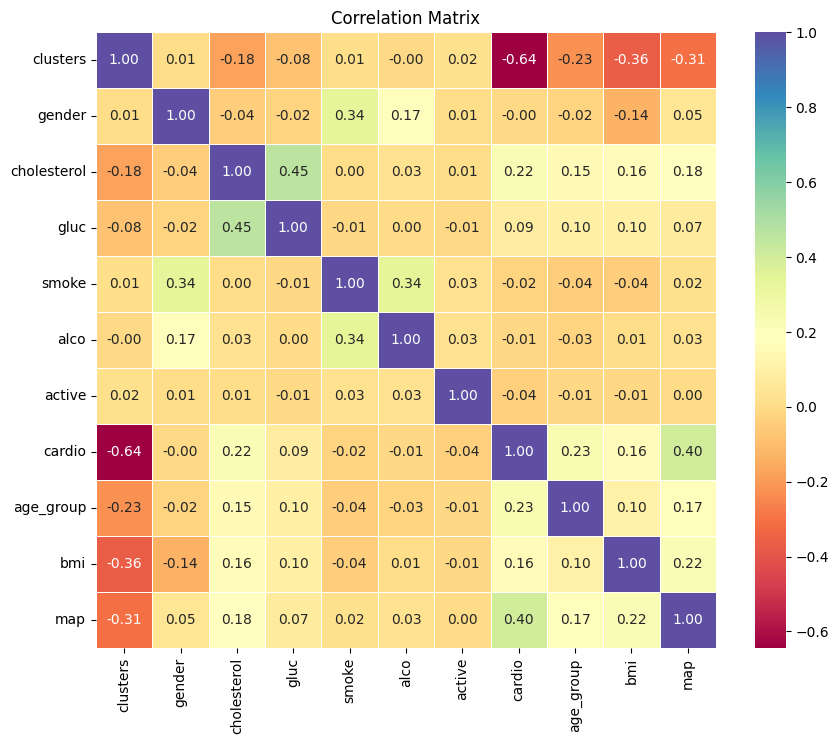

In [24]:
splt.figure(figsize=(10, 8))
seaborn.heatmap(df.corr(), annot=True, cmap='Spectral', fmt=".2f", linewidths=.5)
splt.title('Correlation Matrix')
splt.show()

Correlation Matrix

In [25]:
x = df.drop(['cardio','gender','alco'], axis=1)
y = df['cardio']

x.head()

,clusters,cholesterol,gluc,smoke,active,age_group,bmi,map
0,1,0,0,0,1,3,1,2
1,0,2,0,0,1,4,3,4
2,1,2,0,0,0,4,1,2
3,0,0,0,0,1,3,2,5
4,1,0,0,0,0,3,1,0


Split Data

In [38]:
x = df[[ 'clusters', 'cholesterol', 'gluc', 'smoke',  'active', 'age_group', 'bmi', 'map']]
y = df['cardio']

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=1)

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [43]:

from sklearn import metrics
gbModel = GradientBoostingClassifier()
gbModel.fit(x_train, y_train)
gb_pred = gbModel.predict(x_test)
gb_accuracy = metrics.accuracy_score(y_test, gb_pred) * 100




In [44]:
from sklearn.metrics import accuracy_score
gbModel.fit(x_train, y_train)
y_train_pred = gbModel.predict(x_train)
training_accuracy = accuracy_score(y_train, y_train_pred)




In [45]:
input_dict = { 'clusters': 1, 'cholesterol': 0, 'gluc': 0, 'smoke': 0,  'active': 1, 'age_group': 3, 'bmi': 1, 'map': 2,}
input_data = scaler.transform(pd.DataFrame([input_dict], columns=x.columns))
prediction = gbModel.predict(input_data)
print("Predicted heart disease:", prediction[0])

Predicted heart disease: 0


In [46]:
input_dict = { 'clusters': 0, 'cholesterol': 2, 'gluc': 0, 'smoke': 0,  'active': 1, 'age_group': 4, 'bmi': 3, 'map': 4,}
input_data = scaler.transform(pd.DataFrame([input_dict], columns=x.columns))
prediction = gbModel.predict(input_data)
print("Predicted heart disease:", prediction[0])

Predicted heart disease: 1
